# A quick usage example

The following script should run on any computer. The example creates a capilary filled with water and a small number
of particles within the viewing area of a 60x water imerrsion microscope.

The simulator works by computing a FFT lookup table for each of the particle in the sample. This table hold information
about the scattered field in the reciprocal plane of the microscope. With the table, by changing the phase and amplitude of the coefficients, we can simulate the focal plane adjustments, and the coherence properties of the illuminant.
Scroll down for an example plot using sliders that modify the microscope properties.

The number of particles is kept low so that the example computes fast. For monodisperse systems, use the monodisperse_particles = True
so that the computation of the lookup table is fast.

when using large number of particles, use a suitable GPU backende. The code was tested using mlx.core and cupy. 

In [1]:
import os

import miepom.core as mp
import numpy as np

USEGPU = False

try:
    import mlx.core as mx
    mp.set_backend(mx)
    USEGPU = True
except ImportError:
    pass
    
try:
    import cupy as cp
    mp.set_backend(cp)
    USEGPU = True
except ImportError:
    pass

if USEGPU == False:
    print("GPU backend not available, using CPU backend. For better performance, install mlx or cupy.")




MIEPOM backend set to mlx.core


In [2]:

sensor_settings = {"shape": (512, 512) ,  
                   "pixel_size": 6.9e-6,  
                   "adcbit": 10,  
                   "pixel_aspect" : 1.0, 
                   "full_well_capacity": 2**15,  
                   "transmittance": 1.}

light_source_settings = {"wavelength": 532e-9,
                       "bandwidth": 29e-9,
                       #inntensity at the object plane
                       # because we are using 60x magnification, the intensity at the object plane is 60x60 times higher 
                       # than the intensity at the image plane, so we need to multiply the intensity by 60*60 
                       "intensity": 60*60}

microscope_settings = {"magnification": 60, 
                       "tube_lens_focal_length": 200e-3, 
                       # The refractive index of the immersion medium (e.g., water, oil, etc.)
                       # this is for future use, currently not used in the simulation
                       # currently, the simmulation assumes that the medium in which the particles are suspended has the same refractive index as the immersion medium of the objective lens
                       # regardless of what the user specifies here, the simulation will always use the refractive index of the immersion medium of the objective lens
                       # In the future, we will allow the user to specify the refractive index of the immersion medium to be different from the refractive index of the medium in which the particles are suspended, 
                       "immersion_medium_refractive_index": 1.33,
                       "objective_numerical_aperture": 0.9,
                       "condenser_numerical_aperture": 0.1}

sample_settings = {"diameter_mean": 0.3e-6,
                     "diameter_std": 0.01e-6,
                     "n_particle": 1.59,
                     "n_particle_std": 0.01,
                     "n_medium": 1.33,
                     # small number of particles for quick testing, increase this number for more realistic simulations
                     "num_particles": 40,
                     "sample_thickness": 100e-6
                     }

simulator_settings = {"simulator_na": 1.0, 
                      "focal_plane": 50e-6, 
                      # Whether the particles are considered monodisperse or not - much faster to compute if monodisperse
                      "monodisperse_particles": False}

In [3]:
sensor = mp.create_sensor(**sensor_settings)
sensor.print_info()

Sensor settings
------------------------------------------------------------------------
Sensor shape:               (512, 512)
Sensor height:              3.53 mm
Sensor width:               3.53 mm
Sensor diagonal:            5.00 mm
Pixel size:                 6.90 um
Pixel aspect:               1.0
Exposure level:             0.50
Full well capacity:         32768 e-
ADC applied:                Yes
ADC bit depth:              10 bits
Shot noise applied:         Yes
Shot noise model:           Poisson



In [4]:
light_source = mp.create_light_source(**light_source_settings)
light_source.print_info()

Light source settings
----------------------
Intensity at object plane:  3600.00
Wavelength:                 532.00 nm
Bandwidth (FWHM):           29.00 nm
Frequency:                  5.64e+14 Hz
Wavenumber:                 1.18e+07 1/m
Wavenumber spread (sigma):  2.74e+05 1/m


In [5]:
microscope = mp.create_microscope(light_source=light_source, sensor=sensor, **microscope_settings)
microscope.print_info(full = False)

Microscope settings
----------------------
Magnification:                     60
Tube lens focal length:            2.00e-01 m
Immersion medium refractive index: 1.33
Objective numerical aperture:      0.9
Condenser numerical aperture:      0.1



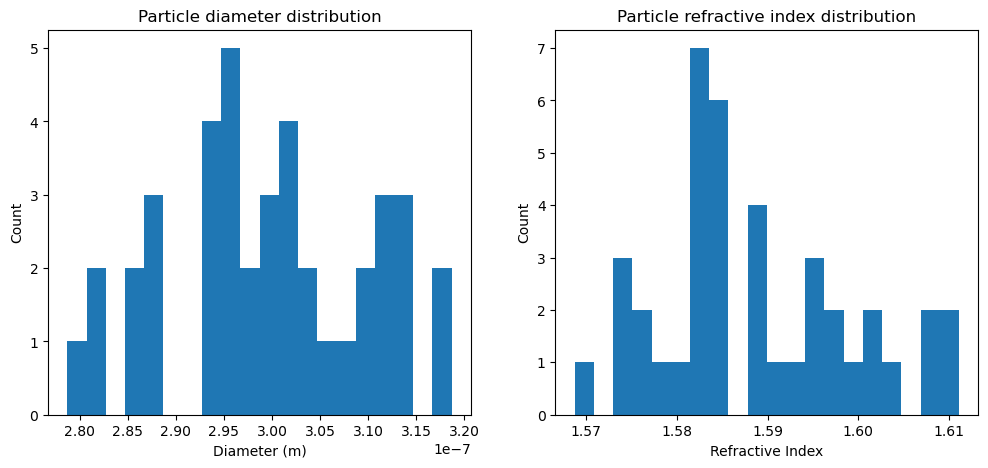

In [6]:
diameter_mean = sample_settings["diameter_mean"]
num_particles = sample_settings["num_particles"]
diameter_std = sample_settings["diameter_std"]
n_mean = sample_settings["n_particle"]
n_std = sample_settings["n_particle_std"]
n_medium = sample_settings["n_medium"]

diameters = np.random.normal(loc = diameter_mean, scale = diameter_std, size = num_particles)
n = np.random.normal(loc = n_mean, scale = n_std, size = num_particles)

particles = mp.create_mie_particles(count = num_particles, diameter = diameters, n_particle = n, n_medium = n_medium)

particles.plot_distribution()

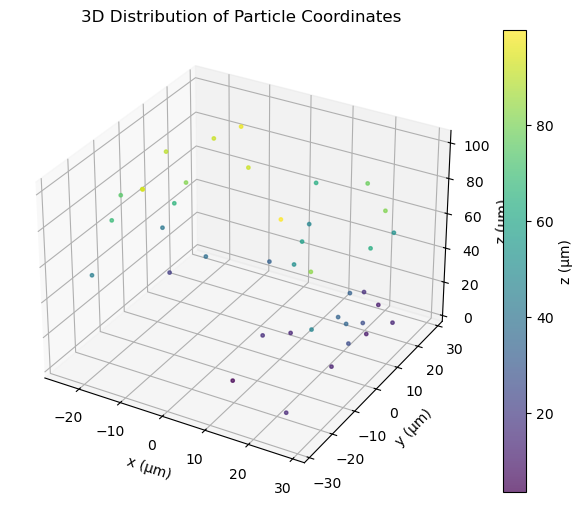

In [7]:

# object plane is the plane where the particles are located, it is defined by the microscope settings
# this object contains information about the size of the object plane, which is determined by the microscope settings and the sensor settings
# it can be used to obtain the dimensions of the object plane, which can be used to generate random coordinates for the particles
# it can also be used to show images 
object_plane = microscope.get_object_plane()

sample_thickness = sample_settings["sample_thickness"]

coordinates = np.zeros((num_particles, 3))
coordinates[:, 0] = np.random.uniform(low = -object_plane.width/2, high = object_plane.width/2, size = (num_particles))
coordinates[:, 1] = np.random.uniform(low = -object_plane.height/2, high = object_plane.height/2, size = (num_particles))
coordinates[:, 2] = np.random.uniform(low = 0, high = sample_thickness, size = (num_particles))

particles.set_coordinates(coordinates)

particles.plot_coordinates()


|==================================================| 100.0 % Done in  0.1 s


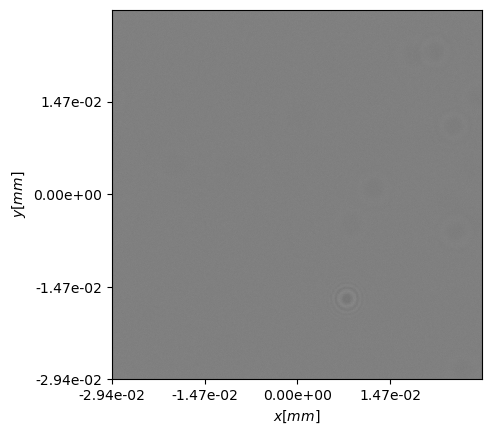

In [8]:
sim = mp.create_simulator(microscope, particles, **simulator_settings)
# Compute the lookup table for the simulator, this is a time-consuming step, but it only needs to be done once for a given set of particles and microscope settings
lut = sim.compute_lut()
im = sim.compute_image()

# make sure we copy the image to a numpy array, because it might be a cupy  array, which cannot be used for plotting with matplotlib
im = mp.get_array(im)

object_plane.imshow(im, cmap="gray", vmin=0, vmax=1)



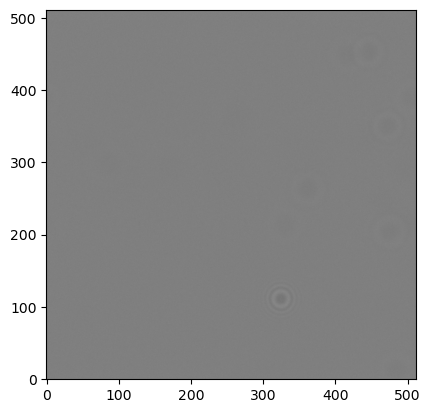

In [9]:
# the imshow function of the object plane is a wrapper around matplotlib's imshow function, which allows to show images in the object plane coordinates, instead of pixel coordinates.
import matplotlib.pyplot as plt
plt.imshow(np.fft.fftshift(im), cmap="gray", vmin=0, vmax=1, origin = "lower")

In [ ]:
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def plot_image_with_controls(focal_plane, condenser_na, bandwidth):
    """Plot simulated image with controls for focal plane, condenser NA, and source bandwidth."""

    # Update optical settings
    sim.set_focal_plane(focal_plane)
    microscope.condenser_numerical_aperture = condenser_na
    light_source.bandwidth = bandwidth 

    # Keep settings dicts in sync (optional)
    microscope_settings["condenser_numerical_aperture"] = condenser_na
    light_source_settings["bandwidth"] = bandwidth

    # Recompute LUT after optical changes
    im_temp = mp.get_array(sim.compute_image())
    coords_um = sim.particles.coordinates * 1e6

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    object_plane.imshow(im_temp, ax=axes[0], cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(
        f"Focal: {focal_plane*1e6:.1f} µm | Cond. NA: {condenser_na:.2f} | BW: {bandwidth*1e9:.1f} nm"
    )
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")

    axes[1].scatter(coords_um[:, 0], coords_um[:, 2], alpha=0.5, s=4)
    axes[1].axhline(focal_plane * 1e6, color="r", linestyle="--", linewidth=2)
    axes[1].set_title("X-Z")
    axes[1].set_xlabel("x (µm)")
    axes[1].set_ylabel("z (µm)")
    axes[1].grid(True, alpha=0.3)

    axes[2].scatter(coords_um[:, 1], coords_um[:, 2], alpha=0.5, s=4, color="orange")
    axes[2].axhline(focal_plane * 1e6, color="r", linestyle="--", linewidth=2)
    axes[2].set_title("Y-Z")
    axes[2].set_xlabel("y (µm)")
    axes[2].set_ylabel("z (µm)")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


focal_plane_slider = FloatSlider(
    value=simulator_settings["focal_plane"],
    min=0,
    max=sample_thickness,
    step=10e-6,
    description="Focal (m):",
    readout_format=".2e",
)

condenser_na_slider = FloatSlider(
    value=microscope_settings["condenser_numerical_aperture"],
    min=0.01,
    max=1.0,
    step=0.01,
    description="Cond. NA:",
    readout_format=".2f",
)

bandwidth_slider = FloatSlider(
    value=light_source_settings["bandwidth"],
    min=1e-9,
    max=100e-9,
    step=1e-9,
    description="BW (m):",
    readout_format=".1f",
)

interact(
    plot_image_with_controls,
    focal_plane=focal_plane_slider,
    condenser_na=condenser_na_slider,
    bandwidth=bandwidth_slider,
)

interactive(children=(FloatSlider(value=5e-05, description='Focal (m):', max=0.0001, readout_format='.2e', ste…

<function __main__.plot_image_with_controls(focal_plane, condenser_na, bandwidth)>

In [11]:
timeit mp.get_array(sim.compute_image())

1.64 ms ± 8.73 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
